Выбранный для работы датасет: https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification

# Задание 1
*Предобработать текстовые данные
Отобразить все основные этапы предобработки текстовых данных*


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/ecommerceDataset.csv")
df.head()

,Household,"Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss.so bring home this elegant print that is lushed with rich colors that makes it nothing but sheer elegance to be to your friends and family.it would be treasured forever by whoever your lucky recipient is. Liven up your place with these intriguing paintings that are high definition hd graphic digital prints for home, office or any room."
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...


Подключив нужный датасет, начнем анализировать его. Код ниже отобразит основные характеристики данных.

In [ ]:
df.shape

(50424, 2)

In [ ]:
df.describe()

,Household,"Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss.so bring home this elegant print that is lushed with rich colors that makes it nothing but sheer elegance to be to your friends and family.it would be treasured forever by whoever your lucky recipient is. Liven up your place with these intriguing paintings that are high definition hd graphic digital prints for home, office or any room."
count,50424,50423
unique,4,27801
top,Household,Think & Grow Rich About the Author NAPOLEON HI...
freq,19312,30


Данный датасет не имеет названий для столбцов, из-за чего записи на первой строке в итоге и стали его названием. Заменим неудобное наименование второго столбца, убрав заодно NaN элементы:

In [ ]:
df['Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss.so bring home this elegant print that is lushed with rich colors that makes it nothing but sheer elegance to be to your friends and family.it would be treasured forever by whoever your lucky recipient is. Liven up your place with these intriguing paintings that are high definition hd graphic digital prints for home, office or any room.'].isna().sum()

np.int64(1)

In [ ]:
df['text'] = df['Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss.so bring home this elegant print that is lushed with rich colors that makes it nothing but sheer elegance to be to your friends and family.it would be treasured forever by whoever your lucky recipient is. Liven up your place with these intriguing paintings that are high definition hd graphic digital prints for home, office or any room.'].fillna('').astype(str)

Проанализируем целевой столбец:

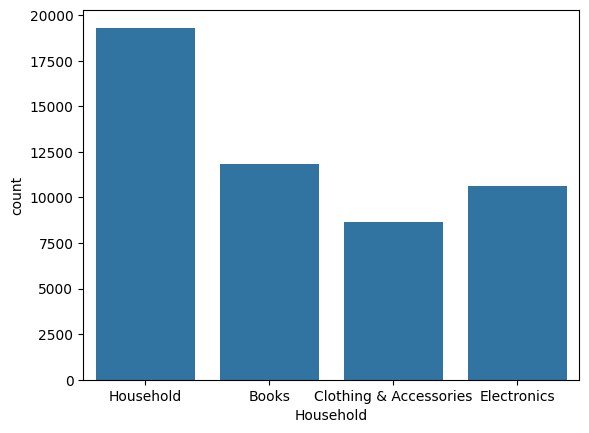

In [ ]:
sns.countplot(data=df, x='Household')
plt.show()

Как мы видим, у нас будет 4 класса, количество которых не сбалансировано. Это может негативно сказаться на качестве будущей модели.

Следующий этап обработки - преобразование текста в более читаемый для алгоритмов вид. Перед самим преобразованием необходимо подгрузить нужные для работы ресурсы nltk, а также инициализировать объект лемматизатора.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Теперь можно заняться самой обработкой текста:
- С помощью библиотеки re производится удаление лишних знаков с из текста, а также текст приводится в более однородный вид
- Затем текст разбивается на токены, которые с помощью лемматизации приводятся в стандартный вид. Также из текста удаляются стоп-слова (часто встречающиеся, но малозначащие слова)

In [ ]:
def prepare_text(text):
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleared_text'] = df['text'].apply(prepare_text)

Следующий этап в решении задачи классификации - векторизация токенов с помощью TF-IDF. Также не стоит забывать перевести данные из первого столбца в числовой вид. После обработки данных, их можно готовить передавать модели для обучения.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

vect = TfidfVectorizer(max_features=10000)
X = vect.fit_transform(df['cleared_text'])
y = df['Household'].map({'Household': 0, 'Books': 1, 'Clothing & Accessories': 2, 'Electronics': 3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Задание 2
Обучить ML-модель для классификации текста

Обосновать выбор метрики и модели ML

Для обучения модели будет использоваться алгоритм RandomForest из-за его способности работать с многоклассовой классификацией, а также устойчивости к дисбалансу классов.

In [ ]:
model = RandomForestClassifier(max_depth=10, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Для проверки качества итоговой модели метрика accuracy не подходит из-за заметного дисбаланса классов. Поэтому для оценки будут использоваться метрики Recall, Precission и F1.

In [ ]:
recall = recall_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print(f'F1: {f1}')

Recall: 0.9011328416582413
Precision: 0.8915632114413444
F1: 0.8947764027680797


Посмотрим детальней на ошибки модели

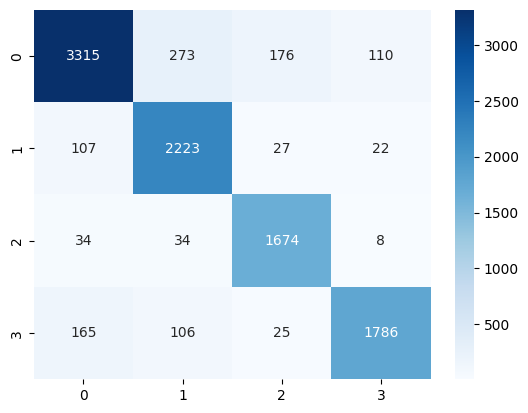

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

Итого мы получили модель с точностью в 90%. Большое количество экземпляров 0 класса привело к множеству ошибочных классификаций. Тем не менее, модель показала высокую эффективность в решении задачи.